## Ejemplo técnicas de deep learning
<div style="border-style:groove;border-width:thin;padding:10px">
Vamos a probar las técnicas de redes neuronales profundas vistas en clase para entrenar una red que distinga entre dos clases de pistachos.
</div>

<div style="border-style:groove;border-width:thin;padding:10px">

Puedes descargar el dataset en <a href="https://www.muratkoklu.com/datasets/">https://www.muratkoklu.com/datasets/</a>
    <p>Tienes dos carpetas con las imágenes para entrenar. Divide, como siempre, el dataset en train, test y validación.</p>
</div>

In [1]:
from os import listdir
from numpy import asarray
from numpy import save
from keras.preprocessing.image import load_img
from keras.preprocessing.image import img_to_array

#Clase kirmizi será la clase 0.0
folder_kirmizi = 'Pistachio_Image_Dataset/Pistachio_Image_Dataset/Kirmizi_Pistachio/'
#Clase siirt será la clase 1.0
folder_siirt = 'Pistachio_Image_Dataset/Pistachio_Image_Dataset/Siirt_Pistachio/'
photos =  []
labels = []

for file in listdir(folder_kirmizi):
    #Cargamos la imagen.
    photo = load_img(folder_kirmizi + file, target_size=(400, 400), color_mode='grayscale')
    #Convertimos la imagen a un array.
    photo = img_to_array(photo)
    #Los guardamos en las listas.
    photos.append(photo)
    labels.append(0.0)

for file in listdir(folder_siirt):
    #Cargamos la imagen.
    photo = load_img(folder_siirt + file, target_size=(400, 400), color_mode='grayscale')
    #Convertimos la imagen a un array.
    photo = img_to_array(photo)
    #Los guardamos en las listas.
    photos.append(photo)
    labels.append(1.0)
    
#Convertimos la lista en un numpy array.
photos = asarray(photos)
labels = asarray(labels)
print(photos.shape, labels.shape)
#Como esto tarda mucho en hacerse vamos a guardar los datos en archivos. 
save('fotos_pistachos.npy', photos)
save('etiquetas_pistachos.npy', labels)


I0000 00:00:1774549316.801776   48149 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1774549319.534264   48149 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1774549324.989308   48149 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


(2148, 400, 400, 1) (2148,)


<div style="border-style:groove;border-width:thin;padding:10px">
Os aconsejo que vayáis guardando la información: save('fotos_pistachos.npy', photos)
</div>

In [2]:
from numpy import load
photos = load('fotos_pistachos.npy')
labels = load('etiquetas_pistachos.npy')
print(photos.shape)

(2148, 400, 400, 1)


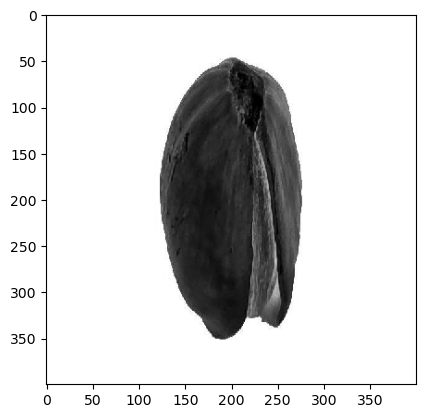

In [3]:
import matplotlib.pyplot as plt
plt.imshow(photos[0], cmap=plt.cm.binary) 

In [5]:
photos = photos.reshape(2148,160000)

In [7]:
from sklearn.preprocessing import StandardScaler
escalador = StandardScaler()
X = photos
X = escalador.fit_transform(X)
y = labels

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.1, random_state = 0)

1. Resuelve el problema con descenso de gradiente.

In [9]:
from tensorflow import keras


In [8]:
model = keras.models.Sequential()
model.add(keras.layers.InputLayer(input_shape=X_train.shape[1:]))
model.add(keras.layers.Dense(100,activation='relu'))
model.add(keras.layers.Dense(50,activation='relu'))
model.add(keras.layers.Dense(10,activation='relu'))
model.add(keras.layers.Dense(1,activation='sigmoid'))

/home/loren/anaconda3/lib/python3.11/site-packages/keras/src/layers/core/input_layer.py:25: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(
2025-04-15 18:59:09.499700: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-04-15 18:59:09.543599: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-04-15 18:59:09.543913: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative val

In [9]:
model.compile(loss='binary_crossentropy', optimizer = keras.optimizers.SGD(learning_rate=0.0001), metrics=['accuracy'])

In [10]:
early_stopping_cb = keras.callbacks.EarlyStopping(patience=10,
restore_best_weights=True)
history = model.fit(X_train, y_train, epochs=100000,validation_split = 0.1,callbacks=[early_stopping_cb])

Epoch 1/100000


I0000 00:00:1744736352.691627   23059 service.cc:145] XLA service 0x7e32dc005d10 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1744736352.691673   23059 service.cc:153]   StreamExecutor device (0): NVIDIA GeForce RTX 2070 with Max-Q Design, Compute Capability 7.5
2025-04-15 18:59:12.717013: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-04-15 18:59:12.847962: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:465] Loaded cuDNN version 8907


13/55 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6603 - loss: 0.6699

I0000 00:00:1744736353.457673   23059 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - accuracy: 0.6766 - loss: 0.6286 - val_accuracy: 0.7887 - val_loss: 0.5143
Epoch 2/100000
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.8391 - loss: 0.4367 - val_accuracy: 0.8402 - val_loss: 0.4480
Epoch 3/100000
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.8602 - loss: 0.3758 - val_accuracy: 0.8454 - val_loss: 0.4179
Epoch 4/100000
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8615 - loss: 0.3505 - val_accuracy: 0.8454 - val_loss: 0.4007
Epoch 5/100000
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.8759 - loss: 0.3173 - val_accuracy: 0.8557 - val_loss: 0.3886
Epoch 6/100000
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.8927 - loss: 0.2972 - val_accuracy: 0.8660 - val_loss: 0.3797
Epoch 7/100000
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.8986 - loss: 0.2863 - val_accuracy: 0.8660 - val_loss: 0.3729
Epoch 8/100000
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9036 - loss: 0.2673 - val_acc

In [11]:
model.evaluate(X_test,y_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.8696 - loss: 0.3373


[0.2895231544971466, 0.8883720636367798]

2. Prueba con los distintos optimizadores (Adam, Nadam, RMSprop) que hemos visto en clase. Pon un callback para que pare cuando lleva 10 épocas sin mejorar. ¿Mejora el resultado respecto al descenso de gradiente?

In [17]:
#ADAM
model = keras.models.Sequential()
model.add(keras.layers.InputLayer(input_shape=X_train.shape[1:]))
model.add(keras.layers.Dense(100,activation='relu'))
model.add(keras.layers.Dense(50,activation='relu'))
model.add(keras.layers.Dense(10,activation='relu'))
model.add(keras.layers.Dense(1,activation='sigmoid'))

In [ ]:
model.compile(loss='binary_crossentropy', optimizer = keras.optimizers.Adam(learning_rate=0.00001, beta_1=0.9, beta_2=0.999), metrics=['accuracy'])

In [19]:
early_stopping_cb = keras.callbacks.EarlyStopping(patience=20,
restore_best_weights=True)
history = model.fit(X_train, y_train, epochs=100000,validation_split = 0.1,callbacks=[early_stopping_cb])

Epoch 1/100000
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - accuracy: 0.7987 - loss: 0.4555 - val_accuracy: 0.8505 - val_loss: 0.3721
Epoch 2/100000
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9162 - loss: 0.2328 - val_accuracy: 0.8608 - val_loss: 0.3529
Epoch 3/100000
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9300 - loss: 0.1822 - val_accuracy: 0.8557 - val_loss: 0.3147
Epoch 4/100000
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9585 - loss: 0.1334 - val_accuracy: 0.8711 - val_loss: 0.3062
Epoch 5/100000
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9624 - loss: 0.1240 - val_accuracy: 0.8814 - val_loss: 0.2934
Epoch 6/100000
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9680 - loss: 0.1077 - val_accuracy: 0.8918 - val_loss: 0.2712
Epoch 7/100000
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9692 - loss: 0.0870 - val_accuracy: 0.8918 - val_loss: 0.2856
Epoch 8/100000
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9830 - loss: 0

In [20]:
model.evaluate(X_test,y_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.8412 - loss: 0.4259


[0.3643859922885895, 0.8558139801025391]

In [10]:
#RMSPROP
model = keras.models.Sequential()
model.add(keras.layers.InputLayer(input_shape=X_train.shape[1:]))
model.add(keras.layers.Dense(100,activation='relu'))
model.add(keras.layers.Dense(50,activation='relu'))
model.add(keras.layers.Dense(10,activation='relu'))
model.add(keras.layers.Dense(1,activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer = keras.optimizers.RMSprop(learning_rate=0.001, rho=0.9), metrics=['accuracy'])

early_stopping_cb = keras.callbacks.EarlyStopping(patience=20,
restore_best_weights=True)
history = model.fit(X_train, y_train, epochs=100000,validation_split = 0.1,callbacks=[early_stopping_cb])


/home/ciabd12/anaconda3/lib/python3.13/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(
W0000 00:00:1774549404.954014   48149 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Epoch 1/100000
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 65ms/step - accuracy: 0.7355 - loss: 4.5397 - val_accuracy: 0.7216 - val_loss: 1.6045
Epoch 2/100000
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 64ms/step - accuracy: 0.7918 - loss: 2.3043 - val_accuracy: 0.7113 - val_loss: 4.0226
Epoch 3/100000
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 63ms/step - accuracy: 0.7608 - loss: 0.9265 - val_accuracy: 0.7577 - val_loss: 2.6984
Epoch 4/100000
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 64ms/step - accuracy: 0.8269 - loss: 0.5068 - val_accuracy: 0.7835 - val_loss: 3.2279
Epoch 5/100000
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 63ms/step - accuracy: 0.8315 - loss: 0.4398 - val_accuracy: 0.8247 - val_loss: 5.7181
Epoch 6/100000
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 64ms/step - accuracy: 0.8666 - loss: 0.4419 - val_accuracy: 0.7423 - val_loss: 0.9921
Epoch 7/100000
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 64ms/step - accuracy: 0.8643 - loss: 0.3734 - val_accuracy: 0.8660 - val_loss: 2.8969
Epoch 8/100000
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 65ms/step - accuracy: 0.8896 - loss: 0

In [11]:
model.evaluate(X_test,y_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8093 - loss: 0.4131 


[0.41312503814697266, 0.8093023300170898]

3. Prueba a cambiar el kernel_initializer de las capas en función de la función de activación de cada capa.

In [ ]:
model = keras.models.Sequential()
model.add(keras.layers.InputLayer(shape=X_train.shape[1:]))
model.add(keras.layers.Dense(200,activation='relu',kernel_initializer='he_normal'))
model.add(keras.layers.Dense(50,activation='relu',kernel_initializer='he_normal'))
model.add(keras.layers.Dense(10,activation='relu',kernel_initializer='he_normal'))
model.add(keras.layers.Dense(1,activation='sigmoid',kernel_initializer='glorot_normal'))

model.compile(loss='binary_crossentropy', optimizer = keras.optimizers.Adam(learning_rate=0.0000001, beta_1=0.9, beta_2=0.999), metrics=['accuracy'])

early_stopping_cb = keras.callbacks.EarlyStopping(patience=30,
restore_best_weights=True)
history = model.fit(X_train, y_train, epochs=100000,validation_split = 0.1,callbacks=[early_stopping_cb])

Epoch 1/100000
55/55 ━━━━━━━━━━━━━━━━━━━━ 7s 71ms/step - accuracy: 0.6242 - loss: 0.6676 - val_accuracy: 0.7062 - val_loss: 0.6570
Epoch 2/100000
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.7332 - loss: 0.5943 - val_accuracy: 0.7732 - val_loss: 0.6128
Epoch 3/100000
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.7862 - loss: 0.5481 - val_accuracy: 0.8041 - val_loss: 0.5821
Epoch 4/100000
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.8225 - loss: 0.5003 - val_accuracy: 0.8351 - val_loss: 0.5580
Epoch 5/100000
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.8425 - loss: 0.4742 - val_accuracy: 0.8247 - val_loss: 0.5394
Epoch 6/100000
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.8424 - loss: 0.4534 - val_accuracy: 0.8454 - val_loss: 0.5234
Epoch 7/100000
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.8418 - loss: 0.4385 - val_accuracy: 0.8454 - val_loss: 0.5093
Epoch 8/100000
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.8584 - loss: 0

In [26]:
history = model.fit(X_train, y_train, epochs=100000,validation_split = 0.1,callbacks=[early_stopping_cb])

Epoch 1/100000
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9743 - loss: 0.0857 - val_accuracy: 0.9175 - val_loss: 0.3050
Epoch 2/100000
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9654 - loss: 0.0934 - val_accuracy: 0.8969 - val_loss: 0.3992
Epoch 3/100000
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9775 - loss: 0.0730 - val_accuracy: 0.9381 - val_loss: 0.2970
Epoch 4/100000
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9896 - loss: 0.0381 - val_accuracy: 0.9175 - val_loss: 0.3302
Epoch 5/100000
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9955 - loss: 0.0230 - val_accuracy: 0.9278 - val_loss: 0.3556
Epoch 6/100000
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9970 - loss: 0.0155 - val_accuracy: 0.9433 - val_loss: 0.3635
Epoch 7/100000
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9978 - loss: 0.0128 - val_accuracy: 0.9330 - val_loss: 0.3307
Epoch 8/100000
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9954 - loss: 0

In [33]:
model.evaluate(X_test,y_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 95ms/step - accuracy: 0.8544 - loss: 0.3642


[0.3191845715045929, 0.8651162981987]

4. Añade normalización entre las capas para que los resultados de una capa pasen normalizados a la siguiente.

In [36]:
model = keras.models.Sequential()
model.add(keras.layers.InputLayer(shape=X_train.shape[1:]))
model.add(keras.layers.Dense(100,activation='relu',kernel_initializer='he_normal'))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Dense(50,activation='relu',kernel_initializer='he_normal'))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Dense(10,activation='relu',kernel_initializer='he_normal'))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Dense(1,activation='sigmoid',kernel_initializer='glorot_normal'))

model.compile(loss='binary_crossentropy', optimizer = keras.optimizers.Adamax(learning_rate=0.0000001, beta_1=0.9, beta_2=0.999), metrics=['accuracy'])

early_stopping_cb = keras.callbacks.EarlyStopping(patience=30,
restore_best_weights=True)
history = model.fit(X_train, y_train, epochs=100000,validation_split = 0.1,callbacks=[early_stopping_cb])

model.evaluate(X_test,y_test)

Epoch 1/100000
55/55 ━━━━━━━━━━━━━━━━━━━━ 7s 60ms/step - accuracy: 0.3677 - loss: 1.0965 - val_accuracy: 0.3660 - val_loss: 0.8057
Epoch 2/100000
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.3806 - loss: 1.0776 - val_accuracy: 0.3763 - val_loss: 0.8703
Epoch 3/100000
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.3853 - loss: 1.0555 - val_accuracy: 0.3711 - val_loss: 0.9047
Epoch 4/100000
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.4052 - loss: 1.0094 - val_accuracy: 0.4227 - val_loss: 0.9154
Epoch 5/100000
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.4107 - loss: 0.9875 - val_accuracy: 0.4485 - val_loss: 0.9183
Epoch 6/100000
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.4112 - loss: 0.9808 - val_accuracy: 0.4536 - val_loss: 0.9123
Epoch 7/100000
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.4516 - loss: 0.9373 - val_accuracy: 0.4588 - val_loss: 0.9022
Epoch 8/100000
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.4513 - loss: 0

[0.40129023790359497, 0.8372092843055725]